# All concept papers downloaded, with field labels: `data.py` export demo

This notebook is a **runnable walkthrough of `data.py`**, the export script for the iteration-2 concept-pool dataset
(artifact `art_eR1Z7fMlOcxs`). That dataset covers **426 concepts** (366 emerging concepts first used 2005-2016 plus 60 stationary
reference concepts), with complete OpenAlex work lists for 2000-2024: **462,812 works** and **488,078 concept-work links**.

`data.py` does no downloading. It reads the hydrated intermediate files (parquet, jsonl, json) and turns every data row into
one example with `input` (JSON string), `output` and `metadata_*` fields, following the pipeline's `exp_sel_data_out` schema.
It groups the rows into **seven datasets**:

| dataset | source file | row = |
|---|---|---|
| `concept_pool_2005_2016` | `hyd/data_out.json` | one concept |
| `concept_work_links` | `hyd/concept_work.parquet` | one (concept, work) link |
| `openalex_works` | `hyd/works/*.parquet` | one OpenAlex work (output = primary-topic subfield) |
| `subfield_year_totals` | `hyd/context/subfield_year_totals.json` | one subfield x year denominator |
| `nativeness_profiles` | `p2/profiles.jsonl` | one (legacy-concept node, 5-year block) subfield-count profile |
| `nativeness_coverage` | `outputs/nativeness_coverage.json` | one pool concept (+ overall row) |
| `venue_habitat_asjc` | `outputs/venue_habitat_asjc.json` | one venue with its journal-level ASJC habitat |

It then splits the examples into parts under a byte limit (`full_data_out/full_data_out_k.json`) and writes `mini_*` and `preview_*`
variants.

**What this demo runs:** the multi-GB source files are not available here, so the demo runs the
**`venue_habitat_asjc`** builder end to end on a curated subset of **100 raw venue records** (`mini_demo_data.json`).
The subset is stratified across every `uncovered_reason`: covered single- and multi-share habitats, the pre-period
fallback, repositories, megajournals, general-only and others. The other builders are shown unchanged for reference.
The splitting, mini and preview code also runs, with a small `PART_LIMIT` so that splitting into parts actually happens.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# orjson, loguru — NOT pre-installed on Colab, always install
_pip('orjson==3.11.3', 'loguru==0.7.3')

# pyarrow, pandas, numpy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')

In [2]:
# --- original import block of data.py ---
import sys
from pathlib import Path

import orjson
import pyarrow.parquet as pq
from loguru import logger

# --- extra imports for the notebook (data loading, d1 stand-in, results/visualisation) ---
import json
from types import SimpleNamespace
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-2/dataset-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("metadata:", data["metadata"]["source"])
print("venues in demo subset:", len(data["venue_habitat_asjc"]["venues"]),
      "| venues in full artifact:", data["metadata"]["n_venues_full"])

metadata: gen_art_dataset_5 outputs/venue_habitat_asjc.json (stratified subset by uncovered_reason, seed 0)
venues in demo subset: 100 | venues in full artifact: 22970


## Configuration

These are all the settings you can change. The values are kept small so the demo runs in seconds.
- `N_VENUES`: how many of the 100 raw venue records to export. The full artifact has **22,970** venues.
- `PART_LIMIT`: byte budget per `full_data_out_k.json` part. The original is **85,000,000** (85 MB). Here it is
  set small so that the ~100-venue demo still splits into several parts.
- `ROOT`: the output directory. In the original this is the script's own folder (`Path(__file__).resolve().parent`).

In [5]:
N_VENUES = 100          # demo subset size (max 100 in mini_demo_data.json; full artifact: 22,970 venues)
PART_LIMIT = 20_000     # original: PART_LIMIT = 85_000_000  (85 MB per part)
ROOT = Path("demo_out")    # original: ROOT = Path(__file__).resolve().parent
ROOT.mkdir(exist_ok=True)

## Setup: paths, the dataset_1 helper module `d1`, and logging

In the original, `data.py` imports `hyd/data.py` as `d1`. That module holds the iteration-1 (dataset_1) builders and the
feature-name constants. The only parts of `d1` that the runnable path needs are `WORK_FEATURES`, `LINK_FEATURES` and
`TOP_META["notes"]`. `mini_demo_data.json` includes them verbatim, so here `d1` is a small namespace built from them.
This is the **only** structural change to the setup. The d1 builders (`concept_meta`, `ds_concept_pool`, `ds_links`,
`ds_denominators`) need the hydrated parquet store, so they are not available in the demo.

In [6]:
HYD = ROOT / "hyd"
# original: sys.path.insert(0, str(HYD)); import data as d1  (hyd/data.py: dataset_1 builders, ROOT = hyd/)
_c = data["metadata"]["d1_constants"]
d1 = SimpleNamespace(WORK_FEATURES=_c["WORK_FEATURES"], LINK_FEATURES=_c["LINK_FEATURES"],
                     TOP_META={"notes": _c["TOP_META_notes"]})

J = lambda o: orjson.dumps(o).decode()  # noqa: E731

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

2

## Builders that need the full hydration store (reference only, not run here)

These are copied unchanged from `data.py`. Each one turns a source file into a list of
`{"input": ..., "output": ..., "metadata_*": ...}` examples:

- **`ds_works`** reads the OpenAlex work parquet shards. `input` is a JSON array in `WORK_FEATURES` order, and `output`
  is the work's primary-topic **subfield id** (the "field label"), or `"unknown"`.
- **`ds_profiles`** reads `p2/profiles.jsonl`: exact OpenAlex subfield counts for each legacy-concept node and 5-year block
  (2000-04, 2005-09, 2010-14, 2015-19). Rows are sorted by coverage rank, then block.
- **`ds_coverage`** reads the per-concept share of host co-occurrence weight whose node has all 4 blocks profiled, and
  appends an `__OVERALL__` row.

The notebook defines them so that the script is complete, but it does not call them: their input files are hundreds of MB
and are not part of the demo data.

In [7]:
def ds_works() -> list[dict]:
    out = []
    cols = d1.WORK_FEATURES + ["subfield_id", "field_id", "domain_id", "retrieval_batch"]
    for p in sorted((HYD / "works").glob("works_part_*.parquet")):
        for r in pq.read_table(p, columns=cols).to_pylist():
            if r["topic_score"] is not None:
                r["topic_score"] = round(float(r["topic_score"]), 4)
            sf = r["subfield_id"]
            out.append({"input": J([r[k] for k in d1.WORK_FEATURES]),
                        "output": str(sf) if sf is not None else "unknown",
                        "metadata_field_id": r["field_id"], "metadata_domain_id": r["domain_id"],
                        "metadata_retrieval_batch": r["retrieval_batch"]})
    return out


def ds_profiles() -> list[dict]:
    out = []
    p = ROOT / "p2" / "profiles.jsonl"
    rows = [orjson.loads(x) for x in p.read_text().splitlines() if x.strip()] if p.exists() else []
    rows.sort(key=lambda r: (r["coverage_rank"], r["block"]))
    for r in rows:
        inp = {"node_id": r["node_id"], "node_type": r["node_type"], "display_name": r["display_name"],
               "level": r["level"], "block": r["block"]}
        outp = {"total": r["total"], "subfield_counts": r["subfield_counts"], "n_groups": r["n_groups"],
                "truncated_top200": r["truncated_top200"]}
        out.append({"input": J(inp), "output": J(outp), "metadata_coverage_rank": r["coverage_rank"],
                    "metadata_host_cooc_weight": r["host_cooc_weight"],
                    "metadata_cum_weight_share": round(r["cum_weight_share"], 6), "metadata_frame": r["frame"],
                    "metadata_retrieved_utc": r["retrieved_utc"], "metadata_credits": r["credits"],
                    "metadata_request_filter": r["request_filter"]})
    return out


def ds_coverage() -> list[dict]:
    d = orjson.loads((ROOT / "outputs" / "nativeness_coverage.json").read_bytes())
    out = []
    for r in d["concepts"]:
        out.append({"input": J({"concept_id": r["concept_id"], "origin_subfield": r["origin_subfield"]}),
                    "output": J({"covered_weight_share": r["covered_weight_share"],
                                 "n_host_cpapers": r["n_host_cpapers"], "n_distinct_nodes": r["n_distinct_nodes"],
                                 "host_weight": r["host_weight"]}),
                    "metadata_phrase": r["phrase"], "metadata_arm": r["arm"], "metadata_origin_rule": r["origin_rule"]})
    o = d["overall"]
    out.append({"input": J({"concept_id": "__OVERALL__", "origin_subfield": None}), "output": J(o),
                "metadata_phrase": None, "metadata_arm": "overall", "metadata_origin_rule": None})
    return out

## The builder the demo runs: `ds_venues` (the `venue_habitat_asjc` dataset)

Each venue (OpenAlex `source_id`) gets a **journal-level ASJC habitat** taken from its SCImago/Scopus categories, under a
rule that was fixed in advance:
- one specific subfield → `habitat_subfield` = that 4-digit ASJC code (**covered**);
- several subfields → `fractional_shares` of 1/k each (`multi_subfield`);
- repositories (arXiv, bioRxiv, ...), megajournals and general-only journals → `UNCOVERED`;
- a small pre-period (2000-04) topic fallback (`route = preperiod_groupby`), which is marked `citation_independent=false`.

The only change from the original is the first line. The raw venue records now come from the loaded `data`, limited to
`N_VENUES`, instead of `outputs/venue_habitat_asjc.json`.

In [8]:
def ds_venues() -> list[dict]:
    # original: d = orjson.loads((ROOT / "outputs" / "venue_habitat_asjc.json").read_bytes())
    d = {**data["venue_habitat_asjc"], "venues": data["venue_habitat_asjc"]["venues"][:N_VENUES]}
    out = []
    for v in d["venues"]:
        inp = {"source_id": v["source_id"], "issn_l": v.get("issn_l"), "issns": v.get("issns"),
               "display_name": v.get("display_name"), "openalex_type": v.get("openalex_type")}
        outp = {"habitat_subfield": v["habitat_subfield"], "fractional_shares": v["fractional_shares"],
                "asjc_codes_raw": v["asjc_codes_raw"]}
        out.append({"input": J(inp), "output": J(outp), "metadata_route": v["route"],
                    "metadata_sjr_year_used": v["sjr_year_used"], "metadata_uncovered_reason": v["uncovered_reason"],
                    "metadata_n_c_papers": v["n_c_papers"], "metadata_citation_independent": v["citation_independent"],
                    "metadata_habitat_in_openalex_subfields": v.get("habitat_in_openalex_subfields"),
                    "metadata_asjc_codes_union_2005_2010_2015_2019": J(v.get("asjc_codes_union_2005_2010_2015_2019")),
                    "metadata_scopus_source_ids": J(v.get("scopus_source_ids")),
                    "metadata_general_field": v.get("general_field"),
                    "metadata_preperiod_dominant_share": v.get("preperiod_dominant_share")})
    return out

## Top-level metadata

`TOP_META` is written into every output part. It records the feature order for the compact array-encoded datasets
(`concept_work_links`, `openalex_works`) and one note per dataset. This cell is unchanged from the original.

In [9]:
TOP_META = {
    "description": "Iteration-2 concept-pool artifact (see README.md). One example per data row, grouped by dataset.",
    "feature_names": {"concept_work_links": d1.LINK_FEATURES, "openalex_works": d1.WORK_FEATURES},
    "notes": {**d1.TOP_META["notes"],
              "subfield_year_totals": "dataset_1 D4 copied unchanged; the 'all_types' variant is the per-10^4 "
                                      "denominator (c-papers include every work type)",
              "nativeness_profiles": "exact OpenAlex meta.count and group_by counts, never sample-based; frame = all "
                                     "types; 'unknown' = works without a primary topic",
              "venue_habitat_asjc": "habitat_subfield = 4-digit ASJC code (= OpenAlex subfield id where one exists) "
                                    "or 'UNCOVERED'; route preperiod_groupby is NOT citation-independent"}}

## Writers: preview truncation, mini/preview files, and size-limited parts

- `trunc` shortens every string to 200 characters, recursively, for the `preview_*` files.
- `write_small` writes `mini_*.json` (the first 3 examples per dataset) and `preview_*.json` (mini, with strings truncated).
- `write_parts` adds examples one by one, measuring each one's serialized size. It starts a new part whenever the next
  example would push the current part over `PART_LIMIT`, splitting a dataset across parts if necessary. Each part then
  gets its own mini and preview files.

This cell is unchanged; `PART_LIMIT` comes from the config cell.

In [10]:
def trunc(o, n: int = 200):
    """Preview variant: every string truncated to n characters (recursively)."""
    if isinstance(o, str):
        return o if len(o) <= n else o[:n] + "..."
    if isinstance(o, list):
        return [trunc(x, n) for x in o]
    if isinstance(o, dict):
        return {k: trunc(v, n) for k, v in o.items()}
    return o


def write_small(path_stem: Path, datasets: list[dict]) -> None:
    """mini_* (3 examples per dataset) and preview_* (mini with strings truncated to 200 chars)."""
    mini = {"metadata": TOP_META, "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:3]}
                                               for d in datasets]}
    (path_stem.parent / f"mini_{path_stem.name}.json").write_bytes(orjson.dumps(mini, option=orjson.OPT_INDENT_2))
    (path_stem.parent / f"preview_{path_stem.name}.json").write_bytes(
        orjson.dumps(trunc(mini), option=orjson.OPT_INDENT_2))


def write_parts(datasets: list[dict]) -> None:
    out_dir = ROOT / "full_data_out"
    out_dir.mkdir(exist_ok=True)
    for old in sorted(out_dir.glob("*.json")):
        old.unlink()
    parts, cur, size = [], [], 0
    for d in datasets:
        chunk = []
        for e in d["examples"]:
            b = len(orjson.dumps(e)) + 1
            if size + b > PART_LIMIT and (chunk or cur):
                if chunk:
                    cur.append({"dataset": d["dataset"], "examples": chunk})
                parts.append(cur)
                cur, chunk, size = [], [], 0
            chunk.append(e)
            size += b
        if chunk:
            cur.append({"dataset": d["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    for k, p in enumerate(parts, 1):
        (out_dir / f"full_data_out_{k}.json").write_bytes(orjson.dumps({"metadata": TOP_META, "datasets": p}))
        write_small(out_dir / f"data_out_{k}", p)
        logger.info(f"part {k}: " + ", ".join(f"{x['dataset']}={len(x['examples'])}" for x in p))
    logger.info(f"wrote {len(parts)} parts to full_data_out/")

## `main()`: build every dataset, split into parts, write the root mini/preview files

The original runs all seven builders. In the demo, the builders whose source files are missing are commented out. Their
lines are kept so the full pipeline is still visible. Everything else is unchanged, including the `if not ex` guard that
leaves out an empty dataset.

In [11]:
@logger.catch(reraise=True)
def main() -> None:
    # cm = d1.concept_meta()   # needs hyd/ hydration store — not in demo
    builders = {
        # "concept_pool_2005_2016": d1.ds_concept_pool,      # hyd/data_out.json — not in demo
        # "concept_work_links": lambda: d1.ds_links(cm),     # hyd/concept_work.parquet — not in demo
        # "openalex_works": ds_works,                        # hyd/works/*.parquet — not in demo
        # "subfield_year_totals": d1.ds_denominators,        # hyd/context/subfield_year_totals.json — not in demo
        # "nativeness_profiles": ds_profiles,                # p2/profiles.jsonl — not in demo
        # "nativeness_coverage": ds_coverage,                # outputs/nativeness_coverage.json — not in demo
        "venue_habitat_asjc": ds_venues,
    }
    datasets = []
    for n, fn in builders.items():
        ex = fn()
        logger.info(f"{n}: {len(ex)} examples")
        if not ex:
            logger.warning(f"{n}: no rows yet, dataset left out of this export")
            continue
        datasets.append({"dataset": n, "examples": ex})
    write_parts(datasets)
    write_small(ROOT / "data_out", datasets)  # root mini_data_out.json / preview_data_out.json: 3 per dataset

In [12]:
main()

20:29:27|INFO   |venue_habitat_asjc: 100 examples


20:29:27|INFO   |part 1: venue_habitat_asjc=28


20:29:27|INFO   |part 2: venue_habitat_asjc=28


20:29:28|INFO   |part 3: venue_habitat_asjc=30


20:29:28|INFO   |part 4: venue_habitat_asjc=14


20:29:28|INFO   |wrote 4 parts to full_data_out/


## Results

Read back what the export wrote: the size and example count of each part, what one exported example looks like (its
`input` and `output` are JSON strings), and how the venues split by habitat rule and route.

Note: `PART_LIMIT` counts only the bytes of the examples. Each part also carries the `TOP_META` header (~1.3 KB), so a
part can end up slightly over the limit. The original script behaves the same way, where 85 MB parts are 85.001 MB on disk.

In [13]:
out_dir = ROOT / "full_data_out"
rows = []
for p in sorted(out_dir.glob("full_data_out_*.json"), key=lambda p: int(p.stem.split("_")[-1])):
    obj = orjson.loads(p.read_bytes())
    rows.append({"part": p.name, "bytes": p.stat().st_size,
                 "examples": sum(len(d["examples"]) for d in obj["datasets"]),
                 "datasets": ", ".join(d["dataset"] for d in obj["datasets"])})
parts_df = pd.DataFrame(rows)
print(f"PART_LIMIT = {PART_LIMIT:,} bytes")
print(parts_df.to_string(index=False))
print("\nfiles written:", sorted(x.name for x in out_dir.iterdir()))

# All exported examples, decoded back into a flat table
exs = [e for p in sorted(out_dir.glob("full_data_out_*.json")) for d in orjson.loads(p.read_bytes())["datasets"]
       for e in d["examples"]]
flat = pd.DataFrame([{**{k: v for k, v in json.loads(e["input"]).items() if k in ("source_id", "display_name", "openalex_type")},
                      **{k: json.loads(e["output"])[k] for k in ("habitat_subfield", "fractional_shares")},
                      "route": e["metadata_route"], "uncovered_reason": e["metadata_uncovered_reason"],
                      "citation_independent": e["metadata_citation_independent"], "n_c_papers": e["metadata_n_c_papers"]}
                     for e in exs])
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 45)
print(f"\n{len(flat)} exported venue examples (first 15):")
print(flat.head(15).to_string(index=False))

print("\nOne exported example (as stored):")
print(json.dumps(exs[0], indent=1)[:1500])

print("\nPreview variant of the root mini file (strings truncated to 200 chars):")
print((ROOT / "preview_data_out.json").read_text()[:800])

PART_LIMIT = 20,000 bytes
                part  bytes  examples           datasets
full_data_out_1.json  20744        28 venue_habitat_asjc
full_data_out_2.json  20608        28 venue_habitat_asjc
full_data_out_3.json  21180        30 venue_habitat_asjc
full_data_out_4.json  10150        14 venue_habitat_asjc

files written: ['full_data_out_1.json', 'full_data_out_2.json', 'full_data_out_3.json', 'full_data_out_4.json', 'mini_data_out_1.json', 'mini_data_out_2.json', 'mini_data_out_3.json', 'mini_data_out_4.json', 'preview_data_out_1.json', 'preview_data_out_2.json', 'preview_data_out_3.json', 'preview_data_out_4.json']



100 exported venue examples (first 15):


 source_id                                                     display_name openalex_type habitat_subfield                                      fractional_shares   route      uncovered_reason citation_independent  n_c_papers
  14366386 Journal of Chromatography B Biomedical Sciences and Applications       journal        UNCOVERED                                                     {}    none        no_match_small                 None           1
  23181512                                                        Nanoscale       journal        UNCOVERED                                                     {} scimago unmapped_sjr_category                 True         702
  24978797                                    Tsinghua Science & Technology       journal        UNCOVERED                                                     {} scimago           megajournal                 True          40
  30869261                                   Atmospheric Pollution Research       journal        UN

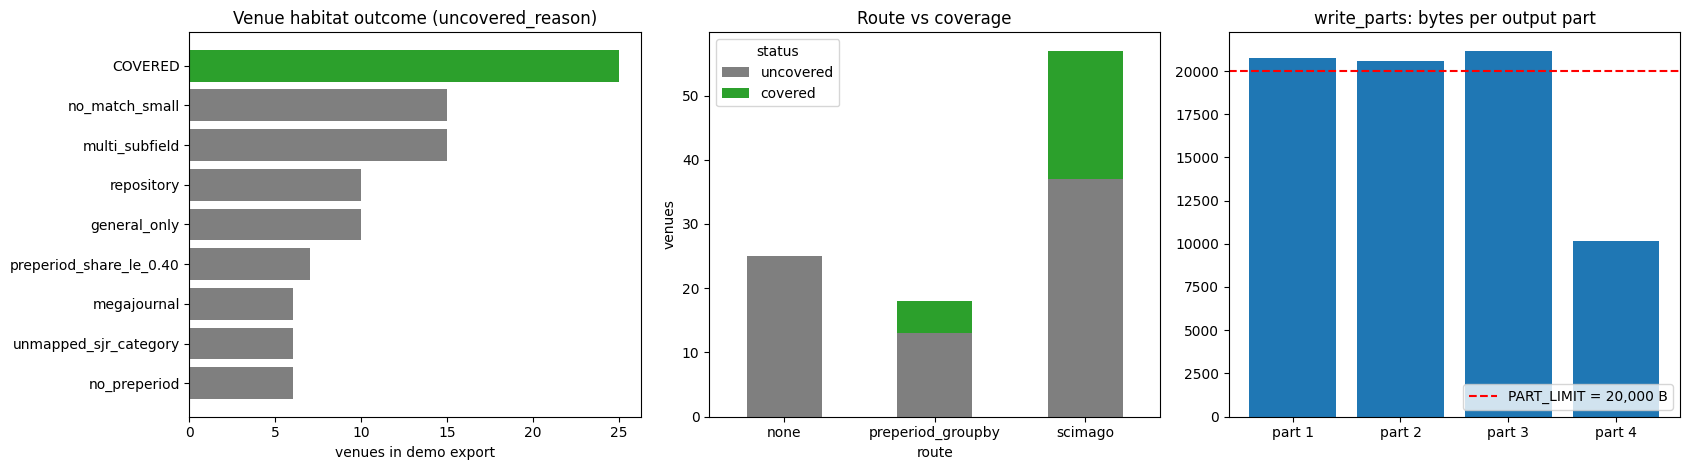

covered venues in this (stratified) demo subset: 25%  (full artifact: 2,929 of 22,970 venues covered; covered venues hold only 12.1% of concept-work links)


In [14]:
flat["status"] = flat["uncovered_reason"].fillna("COVERED")
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

vc = flat["status"].value_counts()
colors = ["tab:green" if s == "COVERED" else "tab:gray" for s in vc.index]
axes[0].barh(vc.index[::-1], vc.values[::-1], color=colors[::-1])
axes[0].set_title("Venue habitat outcome (uncovered_reason)")
axes[0].set_xlabel("venues in demo export")

ct = pd.crosstab(flat["route"], flat["status"] == "COVERED").rename(columns={True: "covered", False: "uncovered"})
ct.plot(kind="bar", stacked=True, ax=axes[1], color={"covered": "tab:green", "uncovered": "tab:gray"}, rot=0)
axes[1].set_title("Route vs coverage")
axes[1].set_ylabel("venues")

axes[2].bar(parts_df["part"].str.replace("full_data_out_", "part ").str.replace(".json", ""), parts_df["bytes"],
            color="tab:blue")
axes[2].axhline(PART_LIMIT, color="red", ls="--", label=f"PART_LIMIT = {PART_LIMIT:,} B")
axes[2].set_title("write_parts: bytes per output part")
axes[2].legend(loc="lower right")
plt.tight_layout()
plt.show()

cov = (flat["status"] == "COVERED").mean()
print(f"covered venues in this (stratified) demo subset: {cov:.0%}  "
      f"(full artifact: 2,929 of 22,970 venues covered; covered venues hold only 12.1% of concept-work links)")